In [32]:
import sys
print("Python:", sys.executable)

# Force install into CURRENT kernel environment
!"{sys.executable}" -m pip uninstall -y face_recognition face-recognition face_recognition_models face-recognition-models setuptools
!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install "setuptools==69.5.1" wheel
!"{sys.executable}" -m pip install "face-recognition-models==0.3.0" "face-recognition==1.3.0"

# Verify
!"{sys.executable}" -m pip show setuptools face-recognition-models face-recognition

Python: c:\GitHub\PyTorchTensor\.venv\Scripts\python.exe
Found existing installation: face-recognition 1.3.0
Uninstalling face-recognition-1.3.0:
  Successfully uninstalled face-recognition-1.3.0
Found existing installation: face_recognition_models 0.3.0
Uninstalling face_recognition_models-0.3.0:
  Successfully uninstalled face_recognition_models-0.3.0
Found existing installation: setuptools 69.5.1
Uninstalling setuptools-69.5.1:
  Successfully uninstalled setuptools-69.5.1
  Using cached setuptools-69.5.1-py3-none-any.whl.metadata (6.2 kB)
Using cached setuptools-69.5.1-py3-none-any.whl (894 kB)
  Using cached face_recognition_models-0.3.0-py2.py3-none-any.whl
  Using cached face_recognition-1.3.0-py2.py3-none-any.whl.metadata (21 kB)
Using cached face_recognition-1.3.0-py2.py3-none-any.whl (15 kB)

   ---------------------------------------- 0/2 [face-recognition-models]
   ---------------------------------------- 0/2 [face-recognition-models]
   ------------------------------------

In [33]:
import pkg_resources
import face_recognition
import face_recognition_models
print("OK")

OK


In [34]:
import sys
print(sys.executable)
!"{sys.executable}" -m pip list | findstr /I "setuptools face-recognition face_recognition_models"

c:\GitHub\PyTorchTensor\.venv\Scripts\python.exe
face-recognition        1.3.0
face_recognition_models 0.3.0
setuptools              69.5.1


# Face Recognition with Eigenfaces and DLIB

In this exercise, we will explore two different methods for face recognition to compare classical and deep learning approaches. The first method will be a classical approach based on Eigenfaces, and the second will be a deep learning approach using DLIB.

# Preparation

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### Loading the dataset

We use the Labeled Faces in the Wild (LFW) people dataset from sklearn, which is a database of aligned grayscale face photographs. It contains 13,233 images of 5,749 people. Each image is centered on a single face. 

We will filter the dataset using `min_faces_per_person=10`, which will leave us with 1183 images of 22 people.

### Task 1: Load the dataset and visualize images

In [36]:
faces = fetch_lfw_people(min_faces_per_person=10, color=True)

X = faces.images
y = faces.target

IMG_H = X.shape[1]
IMG_W = X.shape[2]
N_IDENTITIES = faces.target_names.shape[0]

# TODO: Split the data into a training and testing set, with 20% of the data for testing. Use a random_state of 42.
# Hint: use train_test_split from sklearn.model_selection (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print('Number of identities:', N_IDENTITIES)

X_train.shape=(3459, 62, 47, 3)
X_test.shape=(865, 62, 47, 3)
y_train.shape=(3459,)
y_test.shape=(865,)
Number of identities: 158


Text(0.5, 1.0, 'Identity: Alvaro Uribe')

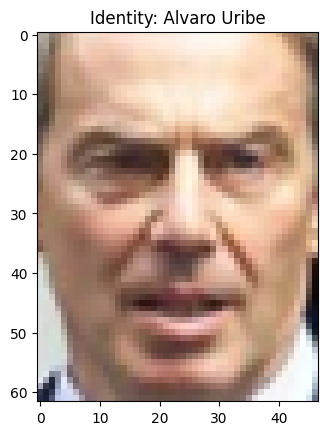

In [37]:
# TODO: visualize some images
# Hint: use plt.imshow (https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)
plt.imshow(X_train[1])
plt.title(f"Identity: {faces.target_names[y_train[0]]}")

## Eigenfaces

Paper: https://direct.mit.edu/jocn/article/3/1/71/3025/Eigenfaces-for-Recognition

Eigenfaces is a classical approach to face recognition. It is based on principal component analysis (PCA), which is a linear dimensionality reduction technique. The idea behind PCA is to find a lower-dimensional representation of a dataset that contains as much information as possible but with fewer features. In our case, each image is a data point with 62*47*3=8742 features. We will use PCA to reduce the dimensionality of the dataset to 150 features.

For the purposes of this exercise, you can think of PCA as simply a classical featurizer. It takes a single image as an input, and outputs a vector of 150 features which we can then use to determine if two images are of the same person.

For the classifier, we will use a Linear Support Vector Classifier (LinearSVC). This is a linear classifier that uses the support vector machine (SVM) algorithm. Essentially, it finds optimal hyperplanes that separate the data points into classes.

In [38]:
from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

### Your Tasks:

1. Create a PCA featurizer with 150 components (https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
2. Create a LinearSVC classifier (https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html#sklearn.svm.LinearSVC)
3. Create a model using `make_pipeline` (https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html)
4. Fit the model to the training data using `model.fit`
5. Evaluate the model on the test data using `model.score`

Hints:
1. Training and testing data must be in the shape (n_samples, n_features), you may need to reshape the data.

In [39]:
# Use PCA to reduce the dimensionality of the data and consider only the most important features
# TODO
pca = PCA(n_components=150, whiten=True, random_state=42)
# Use a linear support vector classifier to classify the faces
# TODO
svc = LinearSVC(random_state=42, max_iter=10000)
# Combine the two into a single pipeline for simplicity
# TODO
model = make_pipeline(pca, svc)


In [40]:
# Note: need to reshape data for PCA in the shape (n_samples, n_features)
# TODO
X_train_flat = X_train.reshape(X_train.shape[0], IMG_H * IMG_W * 3)
X_test_flat = X_test.reshape(X_test.shape[0], IMG_H * IMG_W * 3)
# Fit the model to the training data
# TODO
model.fit(X_train_flat, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pca', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",150
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",True
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy

In [41]:
# Evaluate the model
# TODO
y_pred = model.predict(X_test_flat)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.45


We should be getting around 70% accuracy with this model. This is pretty good and way better than random! However, we still make mistakes about 30% of the time and can do a lot better with a deep learning approach.

# Now let's try a deep learning approach with DLIB

DLIB is a C++ library with Python bindings that contains implementations of many popular computer vision algorithms. It is a very powerful library, and we will only be using a small part of it for this exercise.

DLIB has a pre-trained face recognition model. It is a deep convolutional neural network (CNN) that takes in an image of a face and outputs a 128-dimensional vector, or latent. The idea is that if two images are of the same person, the distance between the two vectors will be small. If the images are of different people, the distance will be large.

We're going to use the `face_recognition` library to work with DLIB and perform face recognition.

In [42]:
import face_recognition

The `face_recognition` library has a function `face_encodings` that takes in an image and returns the 128-dimensional vector. We can use this to featurize our images. To call it, we need to provide the images and the bounding boxes of the faces in the images. Since we know that there is only one face in each image and they're aligned, we can just use the entire image as the bounding box as follows:

```python
face_locations = (0, IMG_W, IMG_H, 0)
face_encodings = face_recognition.face_encodings(image, face_locations)
```

Our pipeline for face recognition will be be the same as before, except instead of PCA we'll use `face_recognition` to featurize the images. The classifier will still be the same, a LinearSVC, trained on the image embeddings.

In [43]:
face_locations = [(0, IMG_W, IMG_H, 0)]

# TODO: convert images into the right format (0-255, 8-bit unsigned integers)
imgs_train = np.clip(X_train, 0, 255).astype(np.uint8)
imgs_test = np.clip(X_test, 0, 255).astype(np.uint8)

train_embs = np.zeros((len(imgs_train), 128))
for i, img in enumerate(imgs_train):
    # TODO: compute the embeddings for the training images
    enc = face_recognition.face_encodings(img, known_face_locations=face_locations)
    train_embs[i] = enc[0] if len(enc) > 0 else np.zeros(128)

In [44]:
# TODO: create and train a linear support vector classifier (LinearSVC) on the embeddings (train_embs) and the labels (y_train)
svc_dlib = LinearSVC(random_state=42, max_iter=10000)
svc_dlib.fit(train_embs, y_train)

# featurize test images and compute accuracy
test_embs = np.zeros((len(imgs_test), 128), dtype=np.float32)
for i, img in enumerate(imgs_test):
    enc = face_recognition.face_encodings(img, known_face_locations=face_locations)
    test_embs[i] = enc[0] if len(enc) > 0 else np.zeros(128, dtype=np.float32)

In [45]:
# TODO: compute the accuracy on the test set. Make sure to featurize the test images first, the same as the training images
y_pred = svc_dlib.predict(test_embs)
accuracy = np.mean(y_pred == y_test)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.1145


This is a lot better!